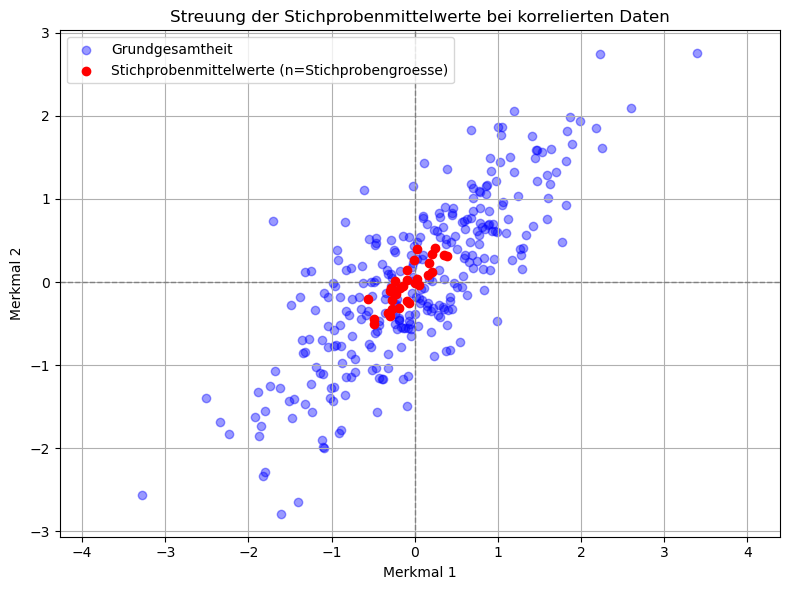

In [5]:
# in diesem Skript soll die Streuung des Mittelwertvektors illustriert werden


import numpy as np
import matplotlib.pyplot as plt

# Reproduzierbarkeit
np.random.seed(42)

# --- Parameter der Verteilung ---
mu = np.array([0, 0])             # Erwartungswert (Mittelwertvektor)
rho = 0.8                         # Korrelation zwischen X1 und X2
sigma = np.array([
    [1, rho],
    [rho, 1]
])                                # Kovarianzmatrix (Standardabweichungen = 1)

# --- 1. Simuliere "Grundgesamtheit" ---
population = np.random.multivariate_normal(mu, sigma, size=300)

# --- 2. Zeichne n_means Mittelwertvektoren aus Stichproben der Größe n_sample ---
n_samples = 20
n_means = 30
mean_points = []

for _ in range(n_means):
    sample = np.random.multivariate_normal(mu, sigma, size=n_samples)
    sample_mean = sample.mean(axis=0)
    mean_points.append(sample_mean)

mean_points = np.array(mean_points)

# --- 3. Visualisierung ---
plt.figure(figsize=(8, 6))

# Grundgesamtheit in Blau
plt.scatter(population[:, 0], population[:, 1], alpha=0.4, label="Grundgesamtheit", color='blue')

# Mittelwertvektoren in Rot
plt.scatter(mean_points[:, 0], mean_points[:, 1], color='red', label="Stichprobenmittelwerte (n=Stichprobengroesse)", zorder=3)

# Koordinatenachsen
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

# Formatierung
plt.title("Streuung der Stichprobenmittelwerte bei korrelierten Daten")
plt.xlabel("Merkmal 1")
plt.ylabel("Merkmal 2")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()
